In [77]:
%pip install pdfplumber polars

In [78]:
import os
import sys
import shutil

repo_name = 'db-wilayah-indonesia'
src_folder_name = 'src'
repo_url = 'https://github.com/ichadhr/db-wilayah-indonesia.git'
target_branch = 'dev'

# Define the full path where the repo will land
repo_path = os.path.join('/content/', repo_name)

# --- Add this section to clean up the existing folder ---
if os.path.exists(repo_path):
    print(f"Existing directory '{repo_name}' found. Removing it...")
    # Recursively remove the directory and all its contents
    shutil.rmtree(repo_path)
    print("Directory removed.")
else:
    print(f"Directory '{repo_name}' not found. Proceeding with clone.")
# --------------------------------------------------------

# Clone the specific branch into the current Colab directory (/content/)
print(f"Cloning '{target_branch}' branch from {repo_url}...")
!git clone -b {target_branch} {repo_url}

# Define the full path to your *source code* directory (abc/src)
src_path = os.path.join(repo_path, src_folder_name)

print(f"Codebase should be located at: {src_path}")
# Use a try block to handle cases where the clone might fail or src folder isn't found
try:
    print(f"Files found in src folder: {os.listdir(src_path)}")
except FileNotFoundError:
    print(f"Error: 'src' folder not found within {repo_name} after cloning.")
    sys.exit(1) # Exit if we can't find the source code

# Add the 'src' directory to the system path so Python can find your code
sys.path.append(src_path)
print("Added 'src' to Python system path. You can now import your modules.")



Existing directory 'db-wilayah-indonesia' found. Removing it...
Directory removed.
Cloning 'dev' branch from https://github.com/ichadhr/db-wilayah-indonesia.git...
Cloning into 'db-wilayah-indonesia'...
remote: Enumerating objects: 710, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 710 (delta 142), reused 206 (delta 136), pack-reused 484 (from 2)
Receiving objects: 100% (710/710), 156.48 MiB | 22.81 MiB/s, done.
Resolving deltas: 100% (392/392), done.
Filtering content: 100% (4/4), 161.37 MiB | 76.15 MiB/s, done.
Codebase should be located at: /content/db-wilayah-indonesia/src
Files found in src folder: ['utils', 'main.py', 'pyproject.toml', 'pipeline', 'datas', 'models', 'extractor', 'scripts', '.env.example', 'notebooks', '__init__.py', 'uv.lock', '.gitignore', 'config']
Added 'src' to Python system path. You can now import your modules.


In [79]:
file_name = "Keputusan_Menteri_Dalam_Negeri_Nomor_300.2.2-2138_Tahun_2025.pdf"
pdf_path = os.path.join(src_path, 'datas', file_name)

In [80]:
detail_settings = {
    # "vertical_strategy": "lines",
    # "horizontal_strategy": "lines",
    # "snap_y_tolerance": 7,
    # "intersection_y_tolerance": 500,
    # "intersection_x_tolerance": 500,
}

In [81]:
start_page_index = 619
end_page_index = 626

page_numbers = list(range(start_page_index, end_page_index + 1))
print(page_numbers)

[619, 620, 621, 622, 623, 624, 625, 626]



Processing page 1:


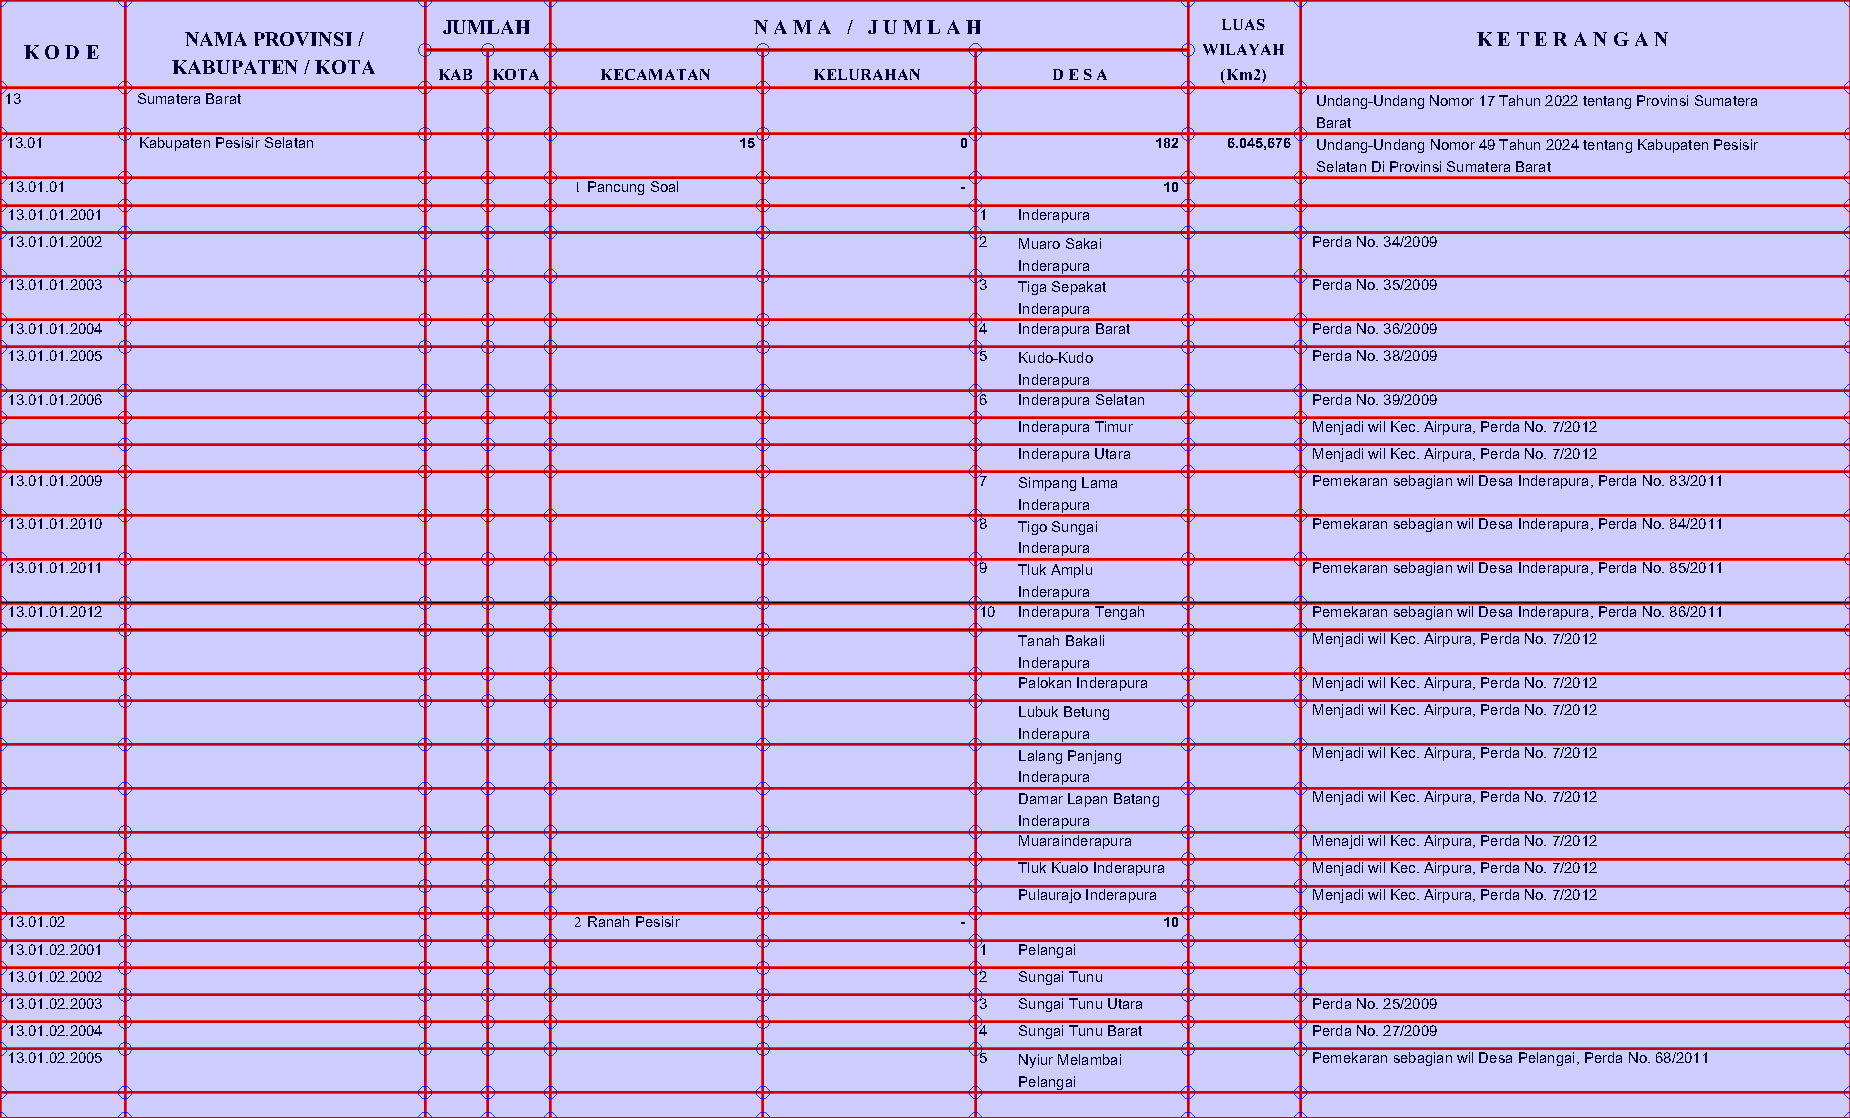


Processing page 2:


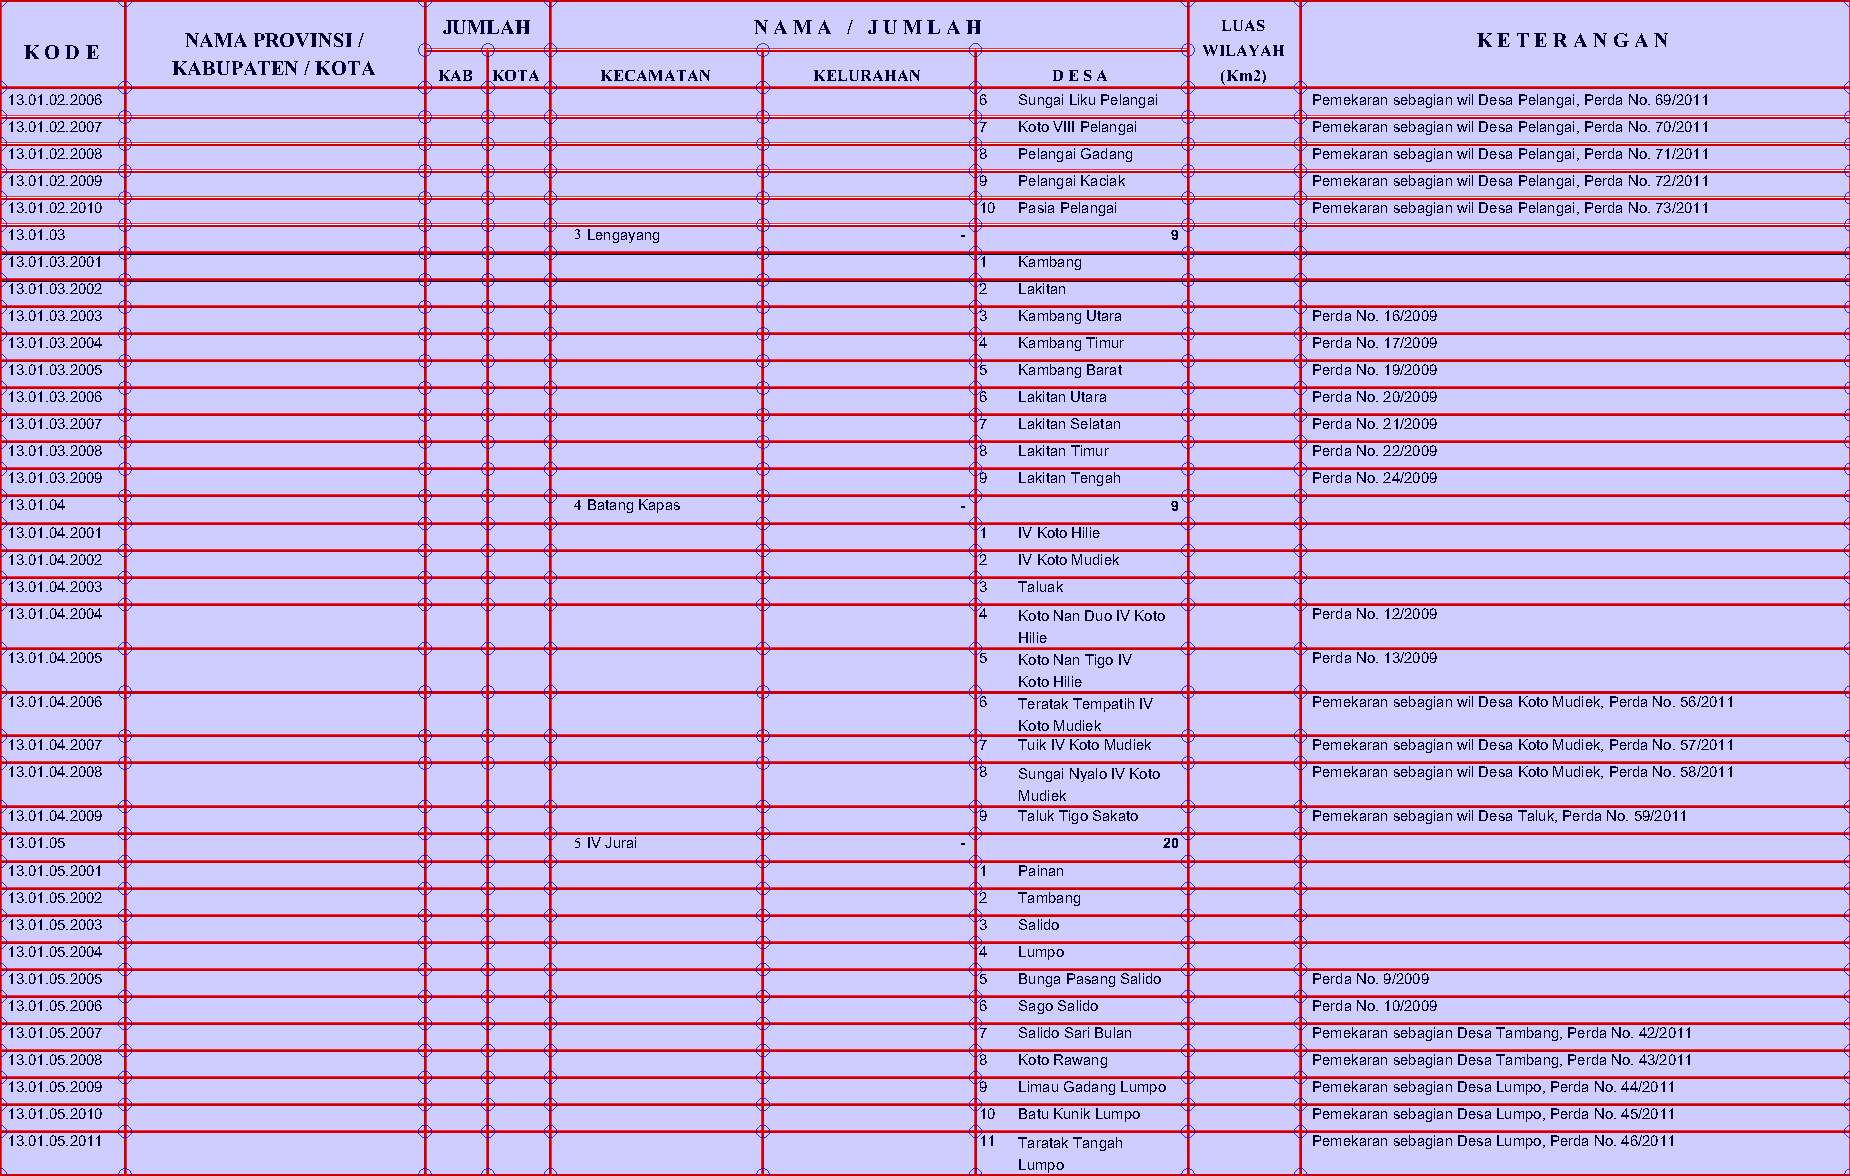


Processing page 3:


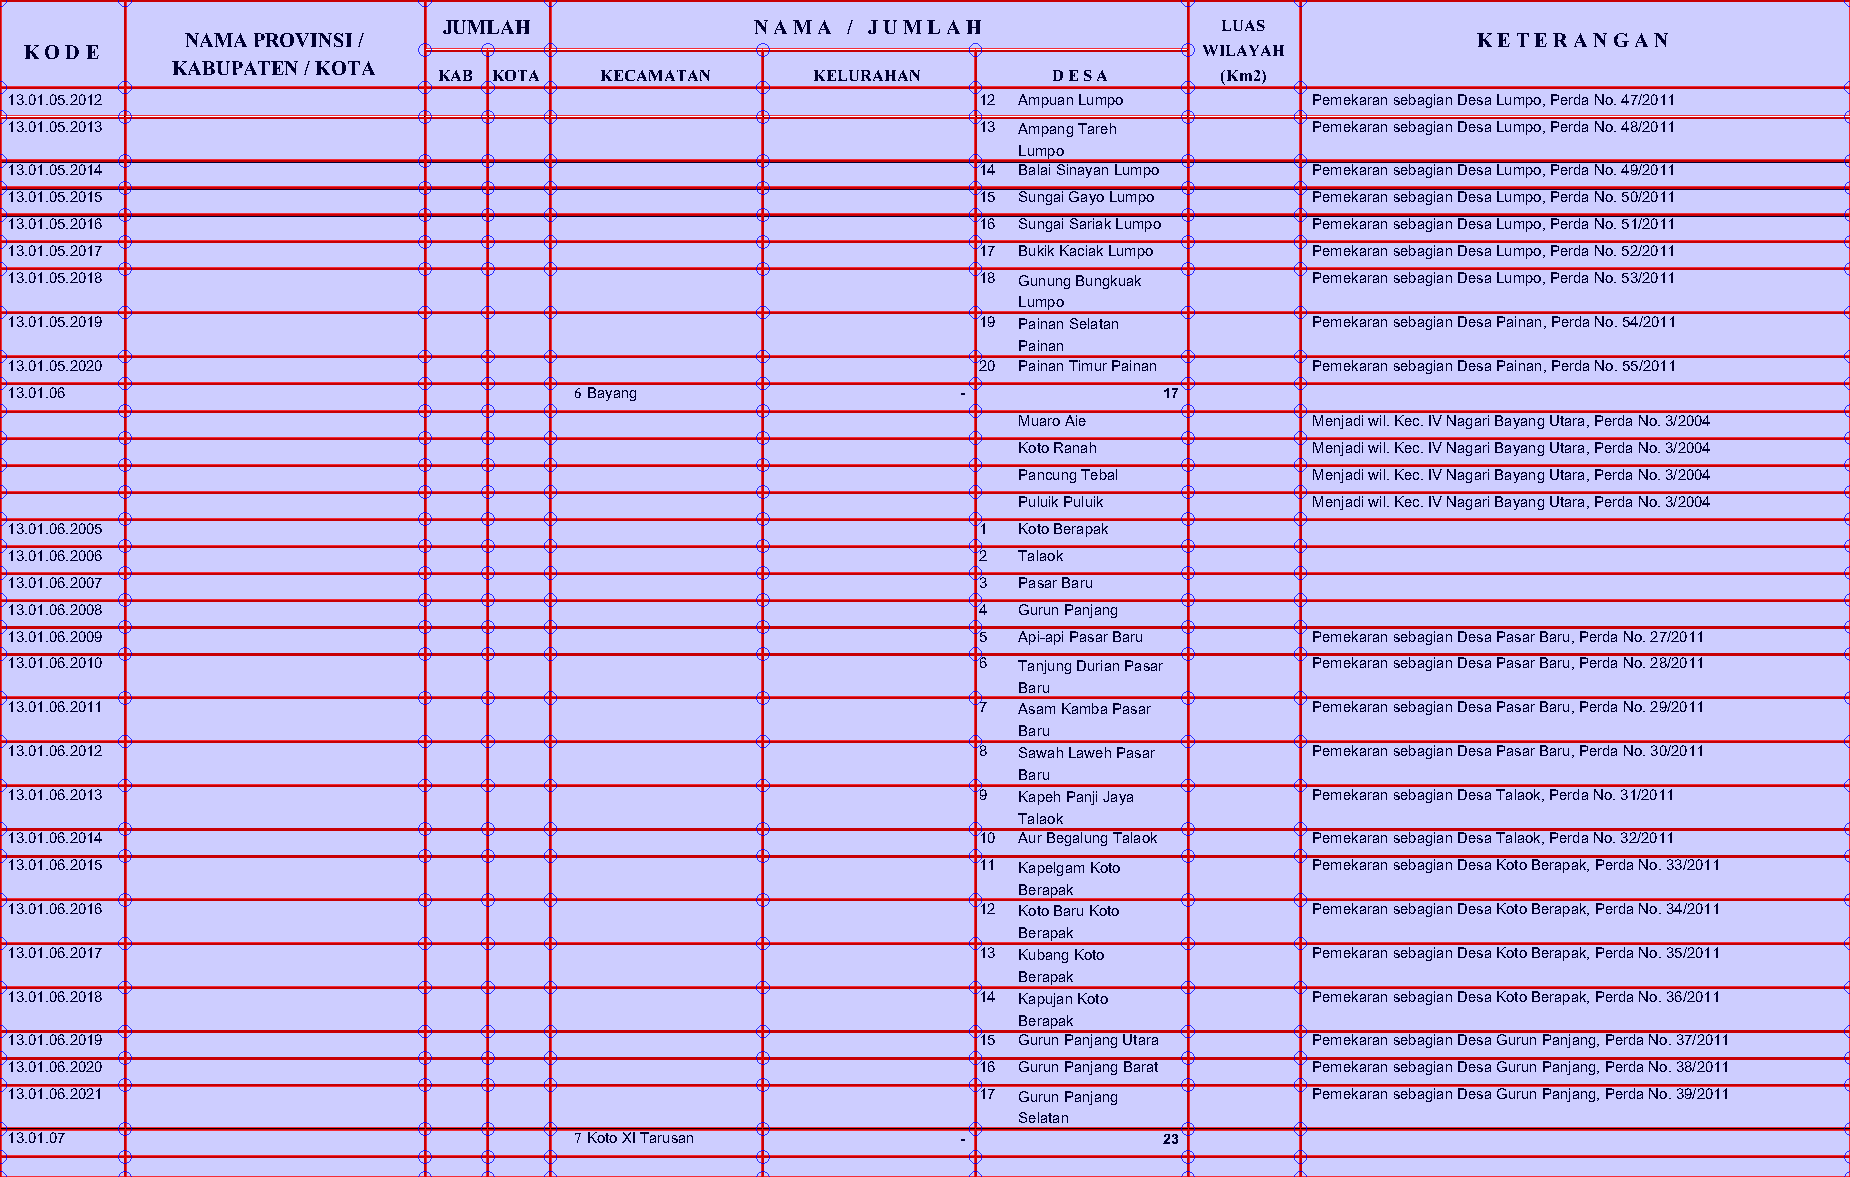


Processing page 4:


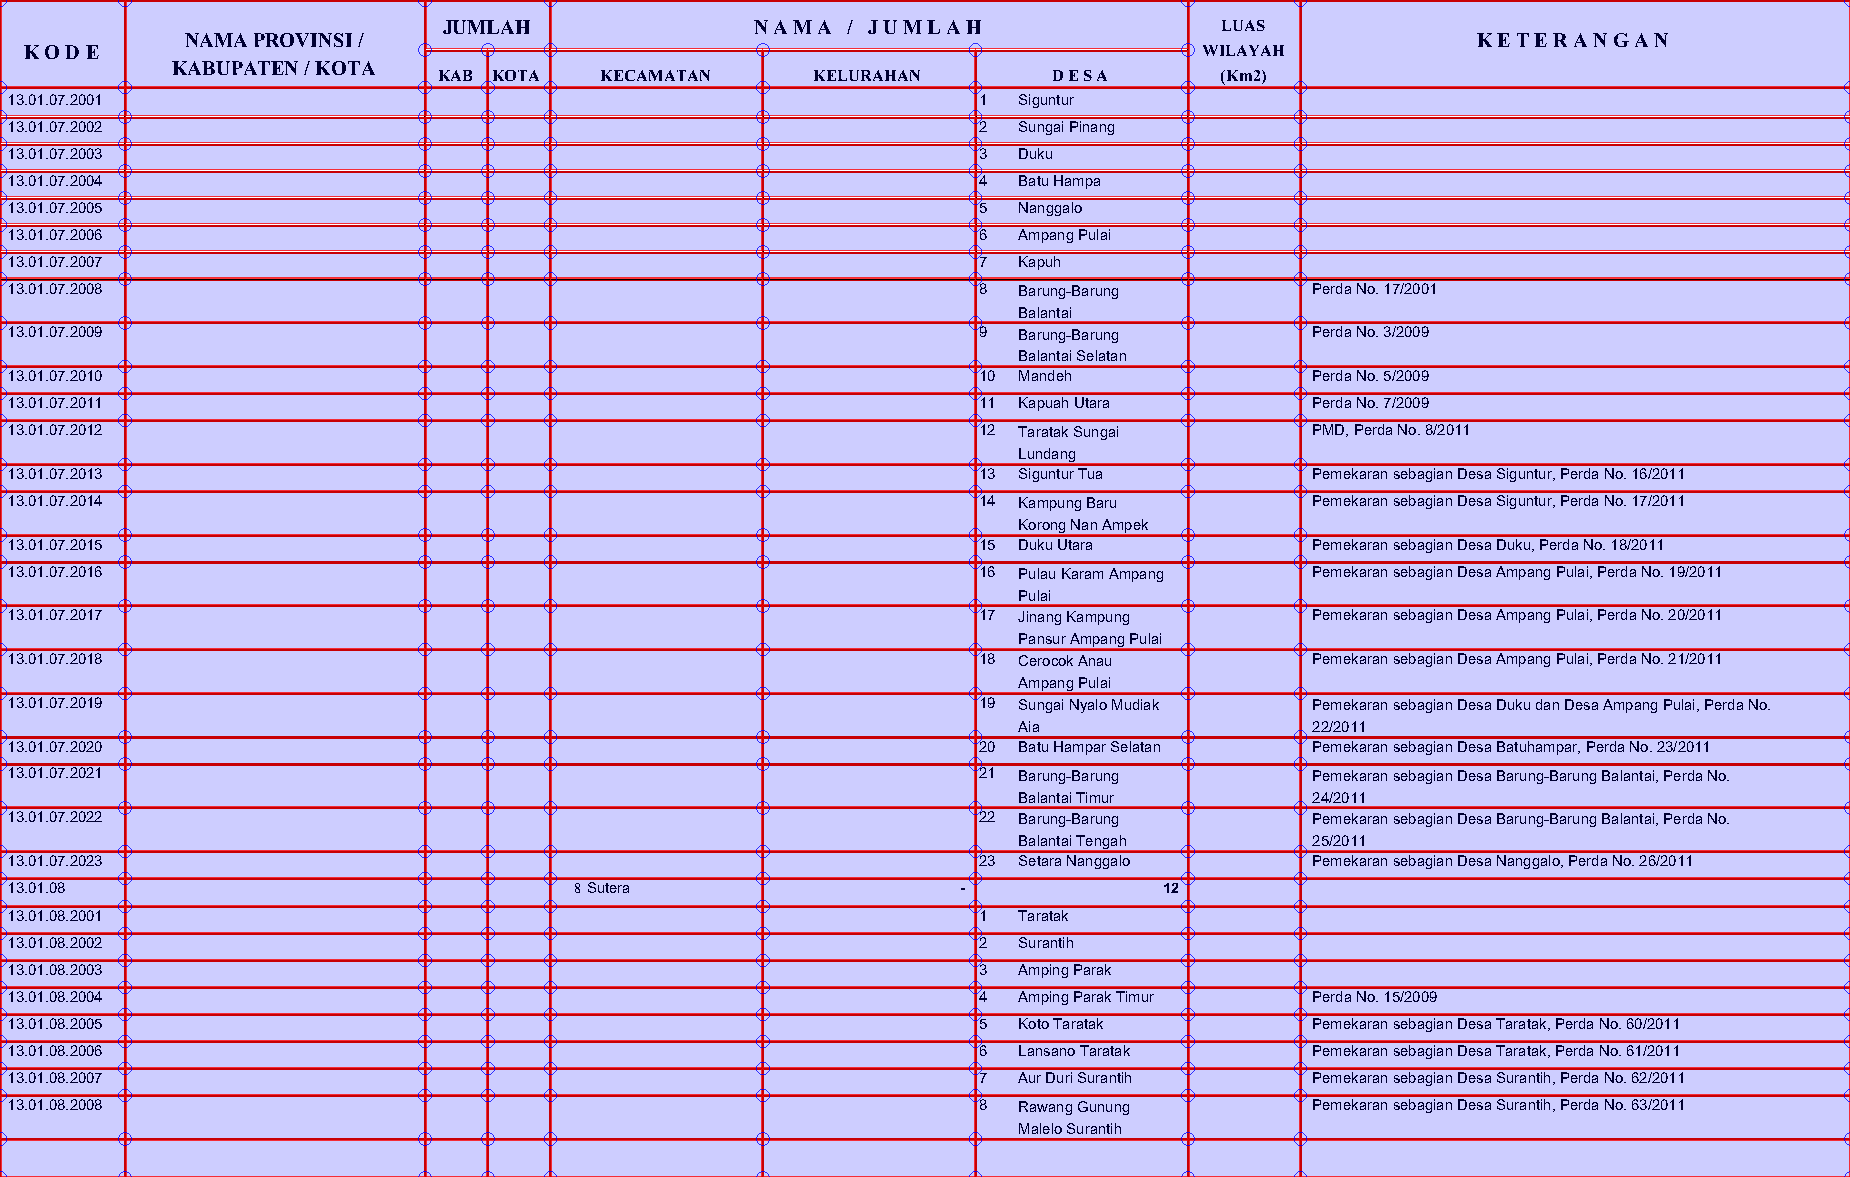


Processing page 5:


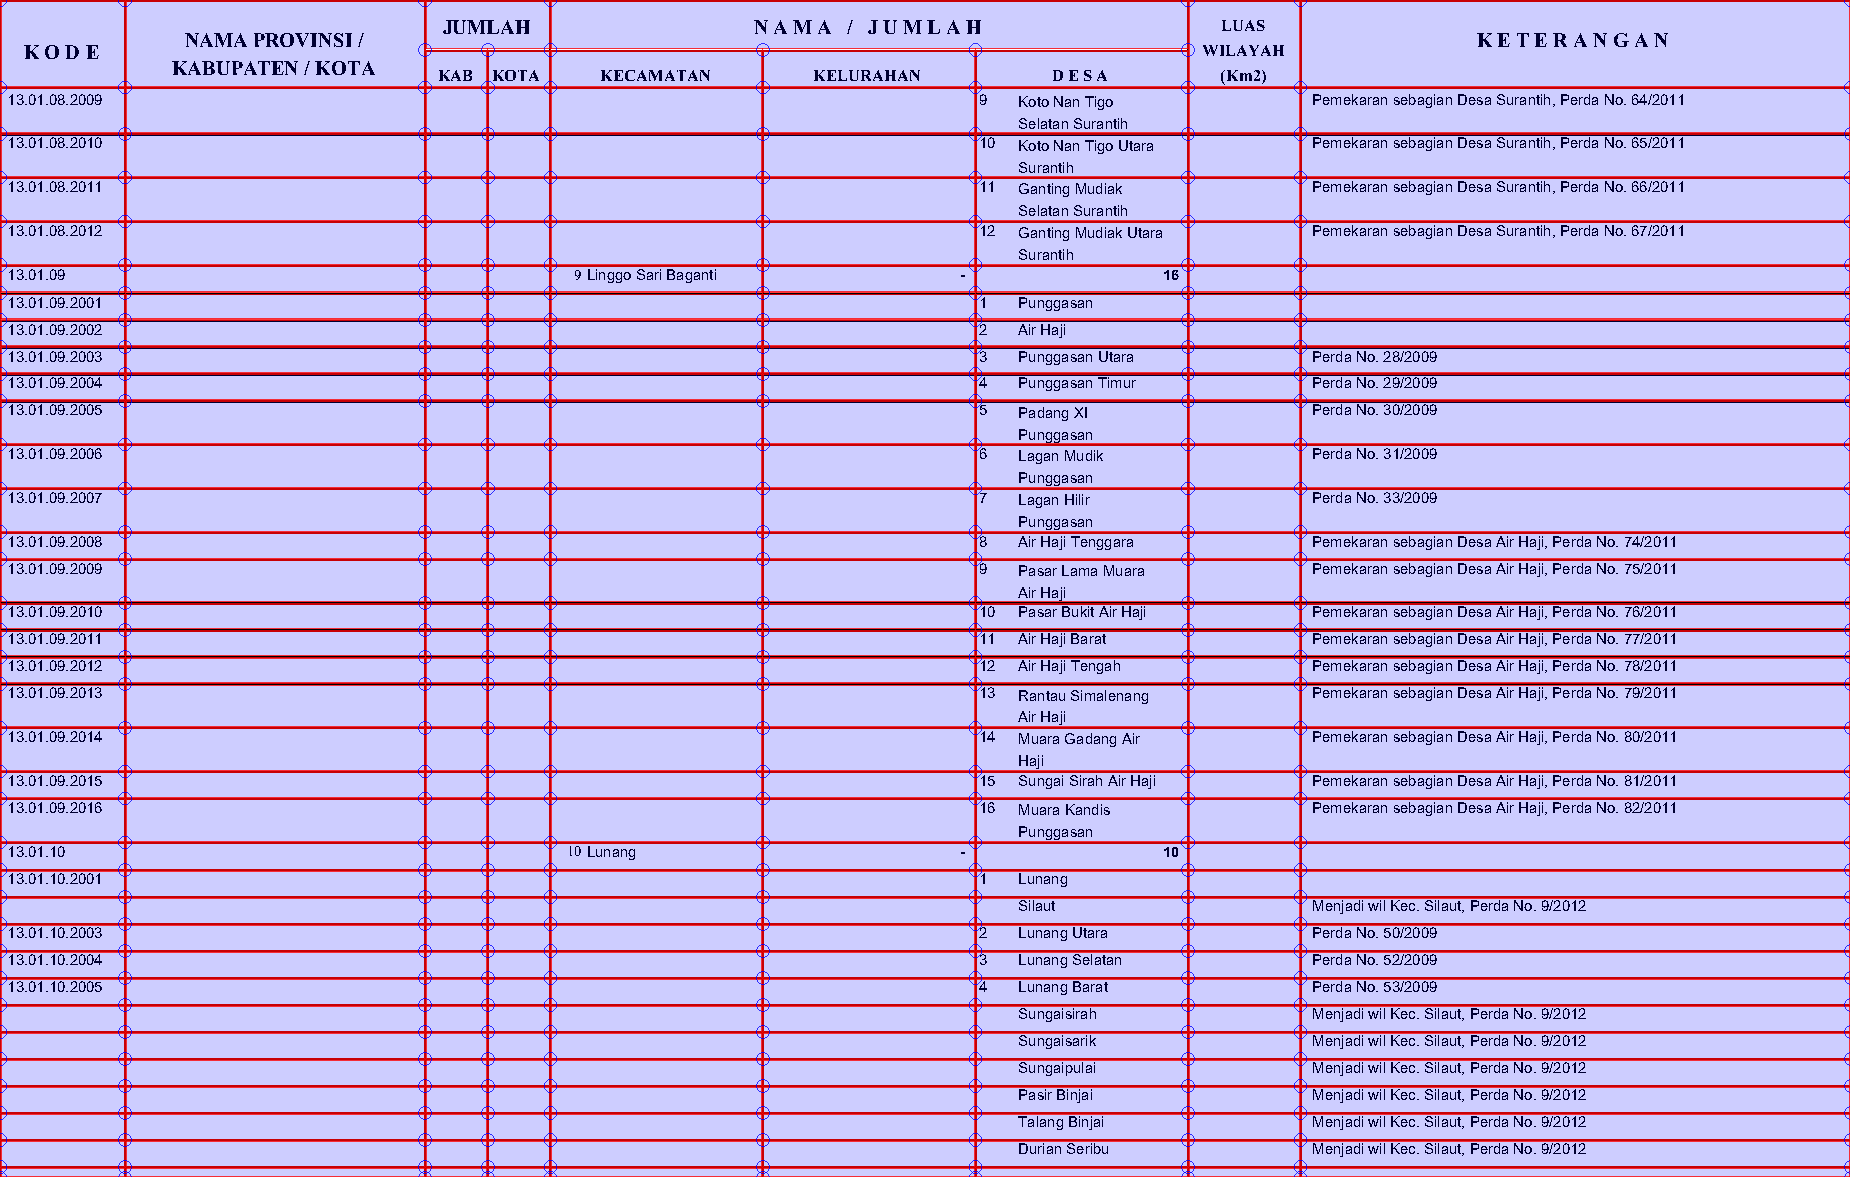


Processing page 6:


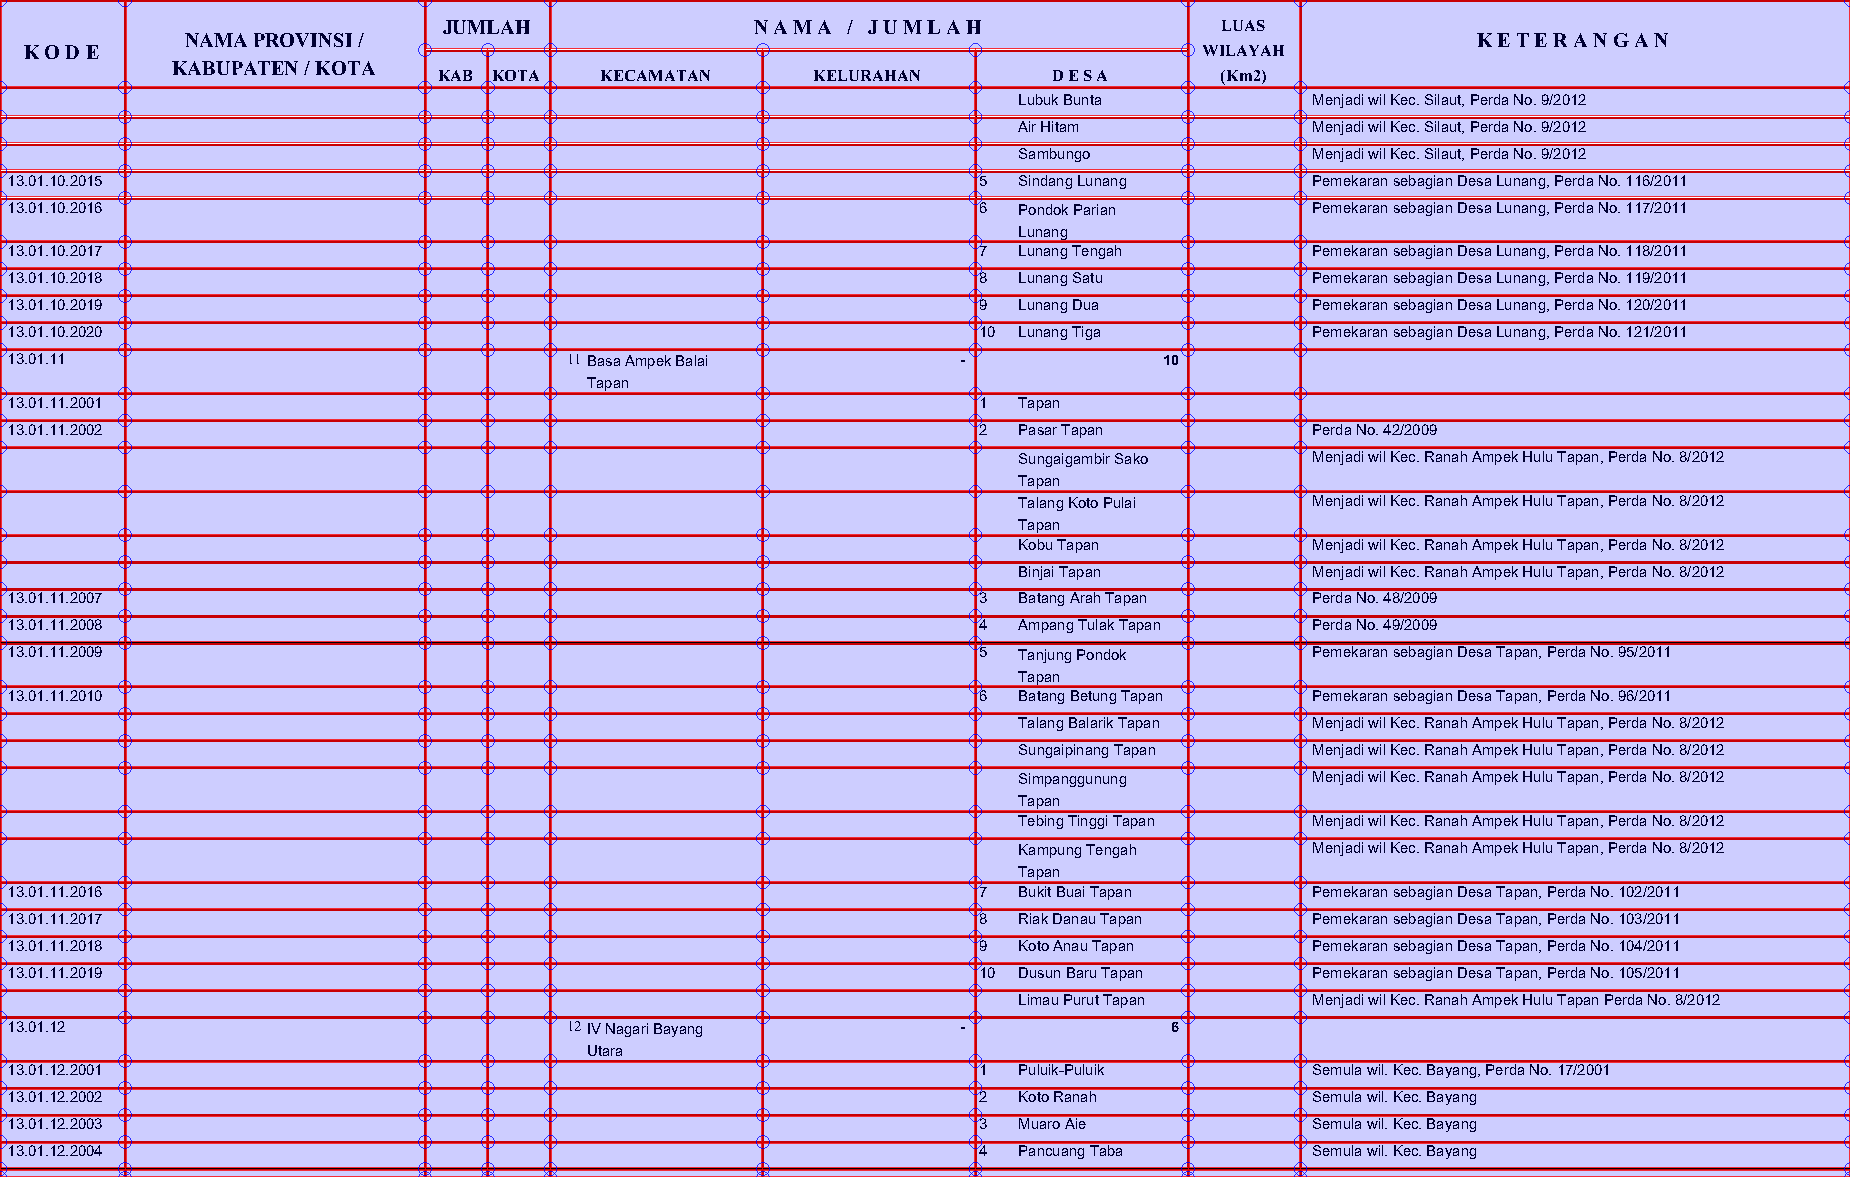


Processing page 7:


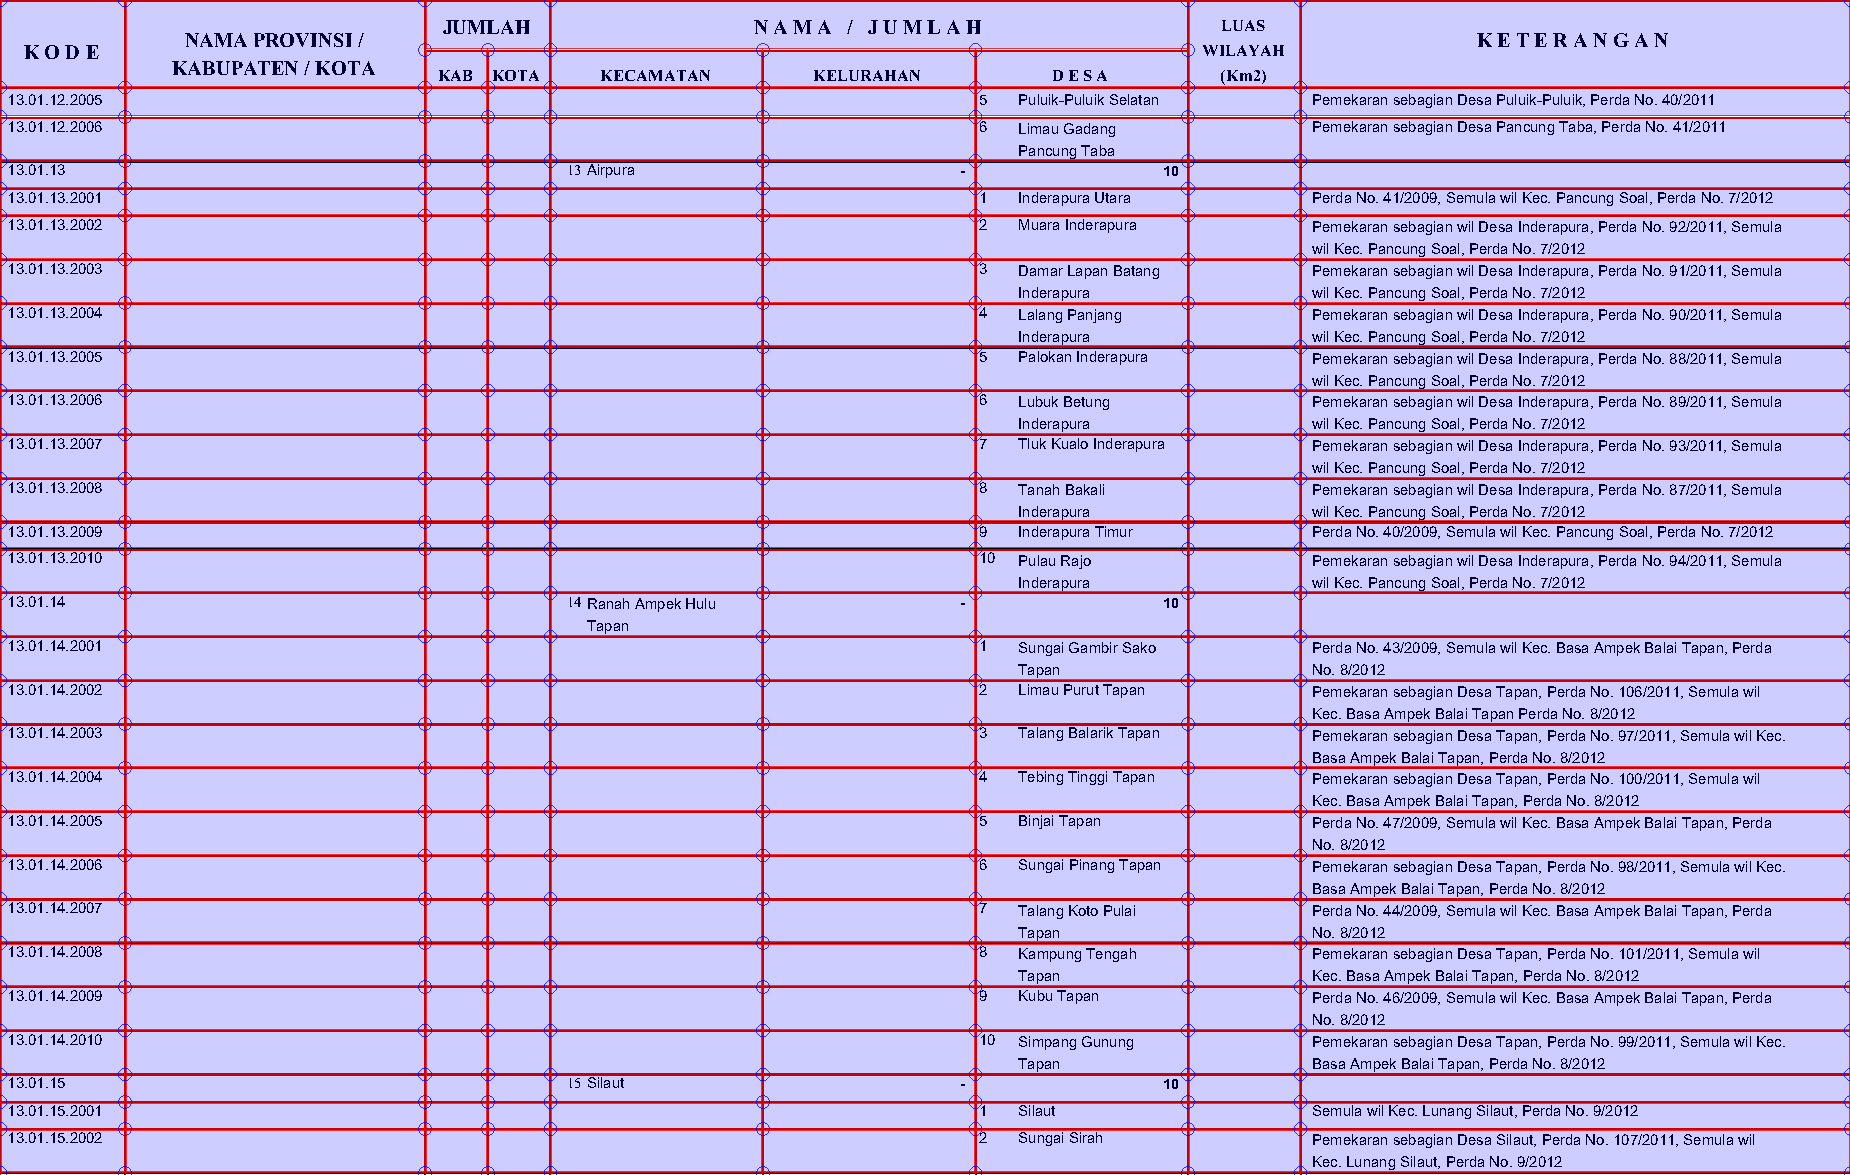


Processing page 8:


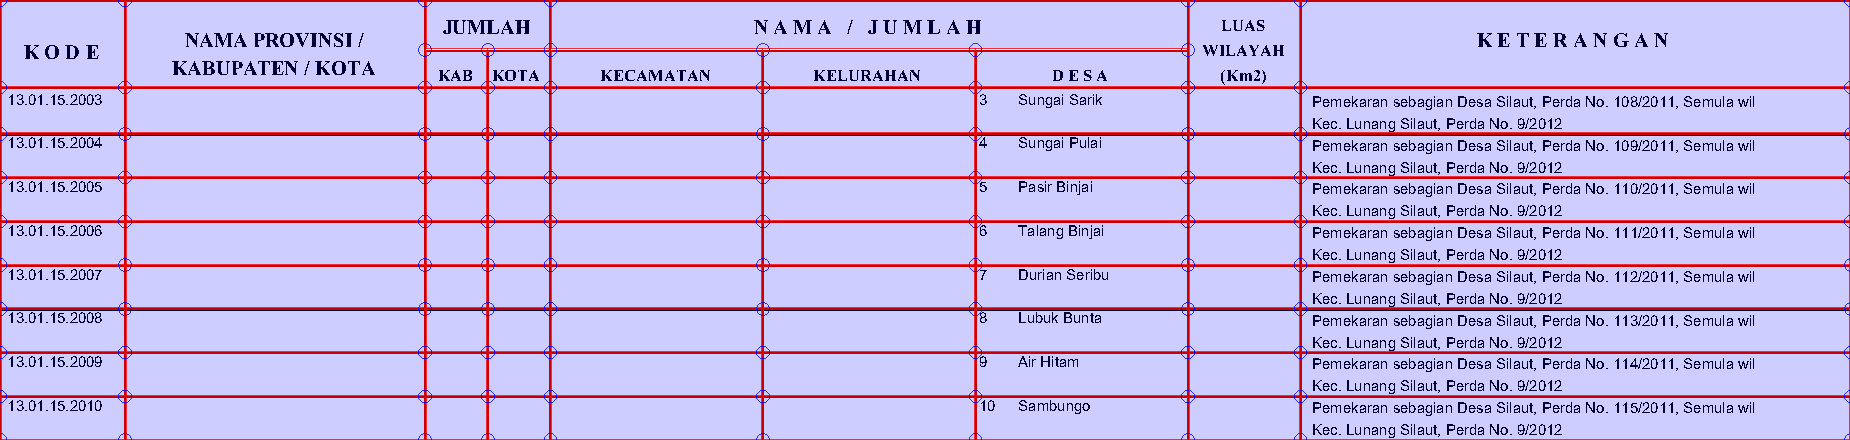

In [82]:
import pdfplumber

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            print(f"\nProcessing page {i + 1}:")
            table = page.find_table()
            if table is not None and table.bbox is not None:
                table_bbox = table.bbox
                the_table = page.crop(table_bbox)
                im = the_table.to_image(resolution=150)
                table_extract = im.debug_tablefinder(detail_settings)
                value_table = the_table.extract_table(detail_settings)
                display(table_extract)
                replacement_value = ""

In [83]:
raw_records = []

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:

        for i, page in enumerate(pdf.pages):
            table = page.extract_table(detail_settings)
            if table is not None:
                for row in table:
                    if any(row) :
                        raw_records.append(row)

In [84]:
def are_sublist_lengths_same(main_list):
    if not main_list:
        return True

    lengths = {len(sublist) for sublist in main_list}
    if len(lengths) == 1:
        return "Ok"
    else:
        raise ValueError("Not same length")


In [85]:
print(are_sublist_lengths_same(raw_records))
print(len(raw_records[0]))

Ok
9


In [86]:
raw_records

[['K O D E',
  'NAMA PROVINSI /\nKABUPATEN / KOTA',
  'JUMLAH',
  None,
  'N A M A / J U M L A H',
  None,
  None,
  'LUAS\nWILAYAH\n(Km2)',
  'K E T E R A N G A N'],
 [None, None, 'KAB', 'KOTA', 'KECAMATAN', 'KELURAHAN', 'D E S A', None, None],
 ['13',
  'Sumatera Barat',
  '',
  '',
  '',
  '',
  '',
  '',
  'Undang-Undang Nomor 17 Tahun 2022 tentang Provinsi Sumatera\nBarat'],
 ['13.01',
  'Kabupaten Pesisir Selatan',
  '',
  '',
  '15',
  '0',
  '182',
  '6.045,676',
  'Undang-Undang Nomor 49 Tahun 2024 tentang Kabupaten Pesisir\nSelatan Di Provinsi Sumatera Barat'],
 ['13.01.01', '', '', '', '1Pancung Soal', '-', '10', '', ''],
 ['13.01.01.2001', '', '', '', '', '', '1 Inderapura', '', ''],
 ['13.01.01.2002',
  '',
  '',
  '',
  '',
  '',
  '2 Muaro Sakai\nInderapura',
  '',
  'Perda No. 34/2009'],
 ['13.01.01.2003',
  '',
  '',
  '',
  '',
  '',
  '3 Tiga Sepakat\nInderapura',
  '',
  'Perda No. 35/2009'],
 ['13.01.01.2004',
  '',
  '',
  '',
  '',
  '',
  '4 Inderapura Barat',
 

In [87]:
from pydantic import BaseModel, field_validator
from utils.text_utils import format_luas, format_number, format_text, normalize_kabupaten_kota, normalize_kecamatan

class DetailsData(BaseModel):
    kode_provinsi: str
    provinsi: str
    jumlah_kabupaten: int
    jumlah_kota: int
    kode_kabupaten_kota: str
    kabupaten_kota: str
    kode_kecamatan: str
    kecamatan: str
    kode_kelurahan: str
    kelurahan: str
    desa: str
    luas_wilayah_km2: float
    keterangan: str

    # Field validators for data type conversion and validation
    @field_validator("jumlah_kabupaten", "jumlah_kota", mode="before")
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode_provinsi", "provinsi",
                     "kode_kabupaten_kota", "kabupaten_kota",
                     "kode_kecamatan", "kecamatan", "kode_kelurahan", "kelurahan", "desa",
                     "keterangan", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        """Normalize all string fields to clean newlines and extra whitespace."""
        return format_text(v)
    
    @field_validator("kabupaten_kota", mode="before")
    @classmethod
    def validate_kabupaten_kota_field(cls, v):
        """Normalize kabupaten_kota field by expanding abbreviations."""
        return normalize_kabupaten_kota(v)
    
    @field_validator("kecamatan", mode="before")
    @classmethod
    def validate_kecamatan_field(cls, v):
        """Normalize kecamatan/kelurahan/desa field by expanding abbreviations."""
        return normalize_kecamatan(v)
    
    # @field_validator("kelurahan", "desa", mode="before")
    # @classmethod
    # def validate_kelurahan_desa_field(cls, v):
    #     """Normalize kelurahan/desa field by expanding abbreviations."""
    #     return normalize_kelurahan_desa(v)

In [88]:
from typing import List, Any

clean_records = []

# Context variables for hierarchical data
current_province = {
    'kode_provinsi': '',
    'provinsi': '',
    'jumlah_kabupaten': 0,
    'jumlah_kota': 0
}

current_regency = {
    'kabupaten_kota': '',
    'jumlah_kecamatan': 0,
    'jumlah_kelurahan': 0,
    'jumlah_desa': 0
}

current_district = {
    'kecamatan': '',
    'kelurahan': '',
    'desa': ''
}

# Helper for safe row access (avoid shadowing)
def safe_row_val(row_data: List[Any], idx: int, default: Any = "") -> Any:
    return row_data[idx] if len(row_data) > idx and row_data[idx] is not None else default


for row in raw_records:
    if not row or len(row) < 9:
        continue

    kode = safe_row_val(row, 0, "")
    prov_kab = safe_row_val(row, 1, "")
    jumlah_kab = safe_row_val(row, 2, "")
    jumlah_kota = safe_row_val(row, 3, "")
    keterangan = safe_row_val(row, 8, "")

    if kode == "" and prov_kab and not prov_kab.isdigit() and prov_kab not in ['KAB', 'KOTA', 'KEC']:
        # Only process real historical districts with meaningful names
        data = DetailsData(
            kode_provinsi=current_province['kode_provinsi'],
            provinsi=current_province['provinsi'],
            jumlah_kabupaten=0,
            jumlah_kota=0,
            kode_kabupaten_kota="",
            kabupaten_kota="",
            kode_kecamatan="",
            kecamatan="",
            kode_kelurahan="",
            kelurahan="",
            desa="",
            luas_wilayah_km2=0.0,
            keterangan=keterangan
        )
        clean_records.append(data)
        continue

    # Skip headers
    if kode in ['K O D E', None] or prov_kab in ['NAMA PROVINSI /\nKABUPATEN / KOTA', None] or jumlah_kab == 'KAB':
        continue

    # Parse codes
    kode_parts = kode.split('.') if kode else []
    if len(kode_parts) < 1:
        continue

    kode_provinsi = kode_parts[0]
    kode_kabupaten_kota = f"{kode_parts[0]}.{kode_parts[1]}" if len(kode_parts) > 1 else ""
    kode_kecamatan = f"{kode_parts[0]}.{kode_parts[1]}.{kode_parts[2]}" if len(kode_parts) > 2 else ""
    kode_kelurahan = kode if len(kode_parts) == 4 else ""

    if len(kode_parts) == 1:  # Province
        # Update context FIRST
        current_province.update({
            'kode_provinsi': kode_provinsi,
            'provinsi': prov_kab,
            'jumlah_kabupaten': int(jumlah_kab) if jumlah_kab.isdigit() else 0,
            'jumlah_kota': int(jumlah_kota) if jumlah_kota.isdigit() else 0
        })

        data = DetailsData(
            kode_provinsi=kode_provinsi,
            provinsi=prov_kab,
            jumlah_kabupaten=safe_row_val(row, 2, ""),
            jumlah_kota=safe_row_val(row, 3, ""),
            kode_kabupaten_kota="",
            kabupaten_kota="",
            kode_kecamatan="",
            kecamatan="",
            kode_kelurahan="",
            kelurahan="",
            desa="",
            luas_wilayah_km2=safe_row_val(row, 7, ""),
            keterangan=keterangan
        )
        clean_records.append(data)

    elif len(kode_parts) == 2:  # Regency
        current_regency.update({
            'kabupaten_kota': prov_kab
        })

        base_data = {
            'kode_provinsi': kode_provinsi,
            'provinsi': current_province['provinsi'],
            'luas_wilayah_km2': safe_row_val(row, 7, ""),
            'keterangan': keterangan
        }

        data = DetailsData(
            **base_data,
            jumlah_kabupaten=0,
            jumlah_kota=0,
            kode_kabupaten_kota=kode_kabupaten_kota,
            kabupaten_kota=prov_kab,
            kode_kecamatan="",
            kecamatan="",
            kode_kelurahan="",
            kelurahan="",
            desa="",
        )
        clean_records.append(data)

    elif len(kode_parts) == 3:  # District
        current_district.update({
            'kecamatan': safe_row_val(row, 4, ""),
            'kelurahan': safe_row_val(row, 5, ""),
            'desa': safe_row_val(row, 6, "")
        })

        base_data = {
            'kode_provinsi': kode_provinsi,
            'provinsi': current_province['provinsi'],
            'luas_wilayah_km2': 0.0,  # Not in district data
            'keterangan': keterangan
        }

        data = DetailsData(
            **base_data,
            jumlah_kabupaten=0,
            jumlah_kota=0,
            kode_kabupaten_kota=kode_kabupaten_kota,
            kabupaten_kota=current_regency['kabupaten_kota'],
            kode_kecamatan=kode_kecamatan,
            kecamatan=safe_row_val(row, 4, ""),
            kode_kelurahan="",
            kelurahan="",
            desa=""
        )
        clean_records.append(data)

    elif len(kode_parts) == 4:  # Sub-district or Village
        subdistrict_name = safe_row_val(row, 5, "")
        village_name = safe_row_val(row, 6, "") 

        data = DetailsData(
            kode_provinsi=kode_provinsi,
            provinsi=current_province['provinsi'],
            jumlah_kabupaten=0,
            jumlah_kota=0,
            kode_kabupaten_kota=kode_kabupaten_kota,
            kabupaten_kota=current_regency['kabupaten_kota'],
            kode_kecamatan=kode_kecamatan,
            kecamatan=current_district['kecamatan'],
            kode_kelurahan=kode_kelurahan,
            kelurahan=subdistrict_name,
            desa=village_name,
            luas_wilayah_km2=0.0,  # Not in village data
            keterangan=keterangan
        )
        clean_records.append(data)
        
clean_records

[DetailsData(kode_provinsi='13', provinsi='Sumatera Barat', jumlah_kabupaten=0, jumlah_kota=0, kode_kabupaten_kota='', kabupaten_kota='', kode_kecamatan='', kecamatan='', kode_kelurahan='', kelurahan='', desa='', luas_wilayah_km2=0.0, keterangan='Undang-Undang Nomor 17 Tahun 2022 tentang Provinsi Sumatera Barat'),
 DetailsData(kode_provinsi='13', provinsi='Sumatera Barat', jumlah_kabupaten=0, jumlah_kota=0, kode_kabupaten_kota='13.01', kabupaten_kota='Kabupaten Pesisir Selatan', kode_kecamatan='', kecamatan='', kode_kelurahan='', kelurahan='', desa='', luas_wilayah_km2=6045.676, keterangan='Undang-Undang Nomor 49 Tahun 2024 tentang Kabupaten Pesisir Selatan Di Provinsi Sumatera Barat'),
 DetailsData(kode_provinsi='13', provinsi='Sumatera Barat', jumlah_kabupaten=0, jumlah_kota=0, kode_kabupaten_kota='13.01', kabupaten_kota='Kabupaten Pesisir Selatan', kode_kecamatan='13.01.01', kecamatan='1Pancung Soal', kode_kelurahan='', kelurahan='', desa='', luas_wilayah_km2=0.0, keterangan=''),
 D

In [89]:
import polars as pl

df = pl.DataFrame([data.model_dump() for data in clean_records])

In [90]:
# Create cleaned version with clean names AND remove moved subdistricts/villages
df_clean = df.with_columns([
    # Clean kelurahan names (remove numbering)
    pl.col("kelurahan").str.replace(r'^\d+\s+', '', literal=False).alias("kelurahan"),
    # Clean desa names (remove numbering)
    pl.col("desa").str.replace(r'^\d+\s+', '', literal=False).alias("desa")
]).filter(
    # Remove moved districts (those with empty subdistrict/village)
    pl.col("kode_kelurahan") != ""
)

In [91]:
df

kode_provinsi,provinsi,jumlah_kabupaten,jumlah_kota,kode_kabupaten_kota,kabupaten_kota,kode_kecamatan,kecamatan,kode_kelurahan,kelurahan,desa,luas_wilayah_km2,keterangan
str,str,i64,i64,str,str,str,str,str,str,str,f64,str
"""13""","""Sumatera Barat""",0,0,"""""","""""","""""","""""","""""","""""","""""",0.0,"""Undang-Undang Nomor 17 Tahun 2…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""""","""""","""""","""""","""""",6045.676,"""Undang-Undang Nomor 49 Tahun 2…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""""","""""","""""",0.0,""""""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2001""","""""","""1 Inderapura""",0.0,""""""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2002""","""""","""2 Muaro Sakai Inderapura""",0.0,"""Perda No. 34/2009"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2006""","""""","""6 Talang Binjai""",0.0,"""Pemekaran sebagian Desa Silaut…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2007""","""""","""7 Durian Seribu""",0.0,"""Pemekaran sebagian Desa Silaut…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2008""","""""","""8 Lubuk Bunta""",0.0,"""Pemekaran sebagian Desa Silaut…"


In [92]:
df_clean

kode_provinsi,provinsi,jumlah_kabupaten,jumlah_kota,kode_kabupaten_kota,kabupaten_kota,kode_kecamatan,kecamatan,kode_kelurahan,kelurahan,desa,luas_wilayah_km2,keterangan
str,str,i64,i64,str,str,str,str,str,str,str,f64,str
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2001""","""""","""Inderapura""",0.0,""""""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2002""","""""","""Muaro Sakai Inderapura""",0.0,"""Perda No. 34/2009"""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2003""","""""","""Tiga Sepakat Inderapura""",0.0,"""Perda No. 35/2009"""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2004""","""""","""Inderapura Barat""",0.0,"""Perda No. 36/2009"""
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.01""","""1Pancung Soal""","""13.01.01.2005""","""""","""Kudo-Kudo Inderapura""",0.0,"""Perda No. 38/2009"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2006""","""""","""Talang Binjai""",0.0,"""Pemekaran sebagian Desa Silaut…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2007""","""""","""Durian Seribu""",0.0,"""Pemekaran sebagian Desa Silaut…"
"""13""","""Sumatera Barat""",0,0,"""13.01""","""Kabupaten Pesisir Selatan""","""13.01.15""","""15Silaut""","""13.01.15.2008""","""""","""Lubuk Bunta""",0.0,"""Pemekaran sebagian Desa Silaut…"
